# Logistic Regression Baseline Model for GSR Classification

This notebook builds a baseline logistic regression model to classify particles as **GSR (1)** or **Non-GSR (0)** using engineered features.

The workflow includes:
- Data loading and inspection
- Target cleaning and encoding
- Feature matrix construction
- Group-aware train/test split
- Model training using a pipeline
- Performance evaluation (confusion matrix, classification report, ROC AUC)
- Model interpretability via feature coefficients

A group-based split is used to prevent **stub-level leakage**, ensuring realistic model evaluation.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_parquet("../../../data/processed/particle_labeled.parquet")

# Inspect structure
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Shape: (2801667, 95)

Columns:
 ['stub_id', 'particle_id', 'relevance_class', 'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr', 'merged_relevance_class', 'final_class', 'label']


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,v,w,xe,y,yb,zn,zr,merged_relevance_class,final_class,label
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR


## Target Cleaning and Filtering

The dataset contains three labels: **GSR**, **Non_GSR**, and **Ambiguous**.  
For this baseline model, we restrict the analysis to binary classification by removing ambiguous observations.

The target variable is encoded as:
- GSR → 1
- Non_GSR → 0

In [2]:
# Filter to binary labels
df = df[df["label"].isin(["GSR", "Non_GSR"])].copy()

# Encode target
df["target"] = df["label"].map({
    "GSR": 1,
    "Non_GSR": 0
})

# Check class balance
print(df["target"].value_counts())

target
0    1216039
1    1078946
Name: count, dtype: int64


## Feature Matrix Construction

For the baseline logistic regression model, predictors were limited to numeric engineered features. Identifier columns and target-related fields were excluded from the predictor matrix.

Initial model results showed that a small number of elemental variables were dominating classification performance, particularly direct GSR-associated elements. To produce a more realistic baseline model, these strongest elemental predictors were removed so the model would rely on broader compositional patterns rather than near-deterministic class indicators.

In [3]:
# Define columns to exclude
exclude_cols = ["label", "target", "stub_id", "particle_id"]

# Keep only numeric candidate predictors
candidate_cols = [col for col in df.columns if col not in exclude_cols]
numeric_cols = [
    col for col in candidate_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

# Remove direct high-signal elemental predictors
direct_signal_cols = ["pb", "sb", "ba"]

feature_cols = [
    col for col in numeric_cols
    if col not in direct_signal_cols
]

X = df[feature_cols].copy()
y = df["target"]
groups = df["stub_id"]

print("Feature count:", len(feature_cols))
print("Removed features:", [c for c in direct_signal_cols if c in numeric_cols])

Feature count: 86
Removed features: ['pb', 'sb', 'ba']


## Train/Test Split (Group-Aware)

To avoid leakage, the dataset is split using `stub_id` as the grouping variable.  
This ensures that particles from the same stub do not appear in both training and test sets.

This is critical because particles within a stub may share underlying structure that could artificially inflate model performance.

In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

train_sample_n = 250000

if len(X_train) > train_sample_n:
    sample_idx = (
        X_train.sample(n=train_sample_n, random_state=42).index
    )
    X_train_fit = X_train.loc[sample_idx].copy()
    y_train_fit = y_train.loc[sample_idx].copy()
else:
    X_train_fit = X_train.copy()
    y_train_fit = y_train.copy()

print("Training rows used for fitting:", len(X_train_fit))

Train shape: (1851761, 86)
Test shape: (443224, 86)
Training rows used for fitting: 250000


## Logistic Regression Pipeline

A baseline logistic regression model was fit using median imputation, standard scaling, and a simplified logistic regression specification.

Because the particle-level dataset is very large, the model was trained on a sampled subset of the training data to improve computational efficiency while preserving a representative baseline evaluation. The model was then evaluated on the held-out test set.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        C=0.5,
        max_iter=300,
        class_weight="balanced",
        random_state=42
    ))
])

pipeline.fit(X_train_fit, y_train_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## Model Evaluation

The model is evaluated using:

- Confusion Matrix
- Classification Report (precision, recall, F1-score)
- ROC AUC score

These metrics provide a comprehensive view of classification performance.

In [6]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC AUC: {roc_auc:.4f}")

Confusion Matrix:
[[185456  47819]
 [ 32159 177790]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8522    0.7950    0.8226    233275
           1     0.7880    0.8468    0.8164    209949

    accuracy                         0.8196    443224
   macro avg     0.8201    0.8209    0.8195    443224
weighted avg     0.8218    0.8196    0.8197    443224


ROC AUC: 0.9006


## ROC Curve

The ROC curve visualizes the tradeoff between true positive rate and false positive rate across different classification thresholds.

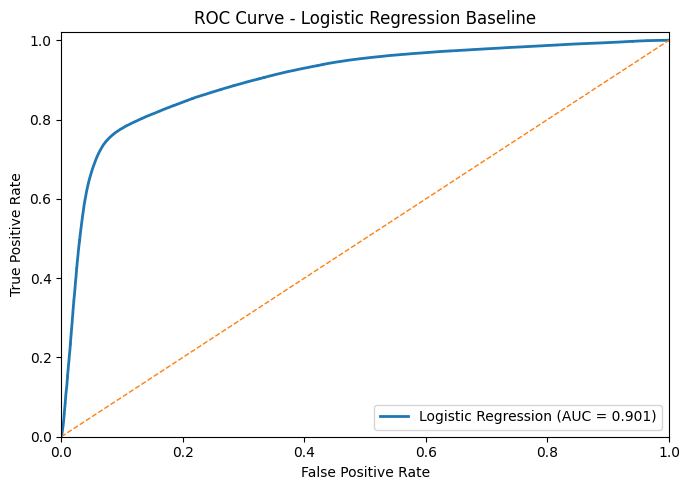

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Baseline")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Feature Importance and Interpretability

Logistic regression coefficients indicate the direction and magnitude of each feature’s influence on the probability of a particle being classified as GSR.

Features with larger absolute coefficients have a stronger impact on model predictions.

In [8]:
coefficients = pipeline.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefficients
})

feature_importance["abs_coef"] = feature_importance["coefficient"].abs()
feature_importance = feature_importance.sort_values(
    by="abs_coef",
    ascending=False
)

feature_importance.head(15)

,feature,coefficient,abs_coef
80,w,-2.641683,2.641683
22,fe,-1.818156,1.818156
84,zn,-1.647419,1.647419
63,s,-1.358866,1.358866
47,o,-0.887540,0.887540
17,cu,-0.834088,0.834088
25,gd,-0.804775,0.804775
24,ga,-0.793823,0.793823
2,al,-0.786109,0.786109
66,si,-0.585391,0.585391


## ROC Interpretation

The ROC curve reflects a more appropriate baseline evaluation because the most dominant direct elemental predictors were removed prior to model fitting. This reduces the likelihood that the model is simply reconstructing the class definition from a small set of highly deterministic elemental indicators.

The resulting baseline model is more useful for comparison with future models because it relies on a broader feature set and a more constrained logistic regression specification.

## Summary

This baseline logistic regression model demonstrates:

- Effective use of engineered features
- Proper handling of group-based data leakage
- Strong interpretability through model coefficients
- Solid evaluation using ROC AUC and classification metrics

This model serves as a benchmark for comparison with more complex modeling approaches.